# 🚁 NOTEBOOK 03: SLIDING WINDOW SEGMENTATION (FINAL FIX)
**Project:** Intelligent Drone Flight Maneuver Recognition  
**Phase:** Data Processing  
**Status:** ✅ FIXED (Segment ID Bug + Window Size Adjustment)

## 🎯 Mục tiêu
1. **Input:** Đọc file CSV sạch từ Notebook 01 (`train_raw_clean.csv`).
2. **Logic:** Cắt dữ liệu thành các cửa sổ (Windows) kích thước cố định.
   - **Sampling Rate:** 100Hz (Cập nhật mới).
   - **Window Size:** 1.0 giây (100 mẫu) -> Để bắt trọn thao tác nhanh (Takeoff/Landing).
   - **Step Size:** 0.2 giây (20 mẫu) -> Overlap 80% để sinh nhiều dữ liệu (Data Augmentation).
3. **Fix Critical Bug:** Sử dụng `ngroup()` để tạo ID duy nhất cho từng lần nhấn nút, tránh việc nhầm lẫn giữa các file zip khác nhau.
4. **Output:** Lưu dưới dạng file binary `.pkl` (Pickle) chứa mảng 3D.

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import pickle
import os
from pathlib import Path
from tqdm import tqdm

drive.mount('/content/drive')

# --- CẤU HÌNH (QUAN TRỌNG) ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')
INTERIM_DIR = BASE_DIR / 'data/interim'
PROCESSED_DIR = BASE_DIR / 'data/processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 🔥 CẤU HÌNH 100HZ & WINDOW 1.0S (Chấp nhận thao tác nhanh)
SAMPLING_RATE = 100
WINDOW_SIZE_SEC = 1.0    # Window 1 giây (Đã hạ từ 2.0s xuống để cứu Takeoff/Landing)
STEP_SIZE_SEC = 0.2      # Trượt 0.2 giây (Overlap 80%)

WINDOW_SIZE = int(SAMPLING_RATE * WINDOW_SIZE_SEC) # 100 mẫu
STEP_SIZE = int(SAMPLING_RATE * STEP_SIZE_SEC)     # 20 mẫu

print(f"⚙️ Config: Window={WINDOW_SIZE} mẫu (1.0s), Step={STEP_SIZE} mẫu (0.2s)")

Mounted at /content/drive
⚙️ Config: Window=100 mẫu (1.0s), Step=20 mẫu (0.2s)


## 🛠️ CORE FUNCTION: WINDOW SLICING

In [2]:
def create_windows_from_segments(df, dataset_name="train"):
    """
    Cắt window từ DataFrame chứa nhiều segment.
    Input: DataFrame (đã load từ CSV)
    Output: List of numpy arrays (Windows), List of labels
    """
    windows = []
    labels = []
    feature_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

    # 🔥 BƯỚC SỬA LỖI QUAN TRỌNG NHẤT: TẠO ID DUY NHẤT TOÀN CỤC
    # Logic cũ bị lỗi vì 'segment_id' = 0 xuất hiện ở cả file Hover.zip lẫn Move_Right.zip
    # Logic mới: Kết hợp (Label + Segment_ID cũ) để tạo thành ID mới không trùng lặp
    if 'unique_seg_id' not in df.columns:
        df['unique_seg_id'] = df.groupby(['label', 'segment_id']).ngroup()

    unique_segments = df['unique_seg_id'].unique()
    print(f"📊 {dataset_name}: Tìm thấy {len(unique_segments)} hành động riêng biệt (Segments).")

    for seg_id in tqdm(unique_segments, desc=f"Processing {dataset_name}"):
        # Lấy dữ liệu của 1 lần nhấn nút cụ thể
        seg_df = df[df['unique_seg_id'] == seg_id].reset_index(drop=True)

        # Lấy nhãn (Vì trong 1 segment nhãn là giống nhau)
        label = seg_df['label'].iloc[0]

        # Bỏ qua nếu quá ngắn (< 1.0s)
        if len(seg_df) < WINDOW_SIZE:
            continue

        # Sliding Window Loop
        for i in range(0, len(seg_df) - WINDOW_SIZE + 1, STEP_SIZE):
            # Cắt lát dữ liệu (chỉ lấy 6 cột features)
            window_vals = seg_df.iloc[i : i + WINDOW_SIZE][feature_cols].values

            windows.append(window_vals)
            labels.append(str(label).upper()) # Chuẩn hóa nhãn in hoa

    return windows, labels

## 🚀 EXECUTE PROCESSING

In [3]:
# 1. Xử lý tập TRAIN
train_file = INTERIM_DIR / 'train_raw_clean.csv'

if train_file.exists():
    print(f"\n📦 Đang xử lý tập TRAIN từ: {train_file.name}")
    df_train = pd.read_csv(train_file)

    X_train, y_train = create_windows_from_segments(df_train, "TRAIN")

    if len(X_train) > 0:
        # Save Pickle
        save_path = PROCESSED_DIR / 'train_windows.pkl'
        with open(save_path, 'wb') as f:
            pickle.dump({'X': X_train, 'y': y_train}, f)

        print(f"✅ DONE TRAIN! Tổng mẫu: {len(X_train)}")
        print(f"💾 Đã lưu tại: {save_path}")
    else:
        print("⚠️ CẢNH BÁO: Không tạo được window nào cho tập Train!")
else:
    print("❌ Không tìm thấy file train_raw_clean.csv. Hãy chạy Notebook 01 trước!")

# 2. Xử lý tập VALIDATION
val_file = INTERIM_DIR / 'val_raw_clean.csv'

if val_file.exists():
    print(f"\n📦 Đang xử lý tập VAL từ: {val_file.name}")
    df_val = pd.read_csv(val_file)

    X_val, y_val = create_windows_from_segments(df_val, "VAL")

    if len(X_val) > 0:
        save_path = PROCESSED_DIR / 'val_windows.pkl'
        with open(save_path, 'wb') as f:
            pickle.dump({'X': X_val, 'y': y_val}, f)
        print(f"✅ DONE VAL! Tổng mẫu: {len(X_val)}")
        print(f"💾 Đã lưu tại: {save_path}")
    else:
        print("⚠️ Val set không tạo được window nào.")


📦 Đang xử lý tập TRAIN từ: train_raw_clean.csv
📊 TRAIN: Tìm thấy 192 hành động riêng biệt (Segments).


Processing TRAIN: 100%|██████████| 192/192 [00:00<00:00, 206.23it/s]


✅ DONE TRAIN! Tổng mẫu: 1750
💾 Đã lưu tại: /content/drive/MyDrive/Drone_Project_2025/data/processed/train_windows.pkl

📦 Đang xử lý tập VAL từ: val_raw_clean.csv
📊 VAL: Tìm thấy 10 hành động riêng biệt (Segments).


Processing VAL: 100%|██████████| 10/10 [00:00<00:00, 160.17it/s]


✅ DONE VAL! Tổng mẫu: 130
💾 Đã lưu tại: /content/drive/MyDrive/Drone_Project_2025/data/processed/val_windows.pkl


## 📊 FINAL CHECK
Kiểm tra phân bố nhãn để đảm bảo không còn lỗi "chỉ có 1 nhãn".


--- PHÂN BỐ DỮ LIỆU HUẤN LUYỆN (TRAIN) ---
IDLE             30
HOVER            27
TURBULENCE       25
MOVE_BACKWARD    10
MOVE_LEFT         9
LANDING           9
MOVE_RIGHT        8
MOVE_FORWARD      8
TAKEOFF           4
Name: count, dtype: int64


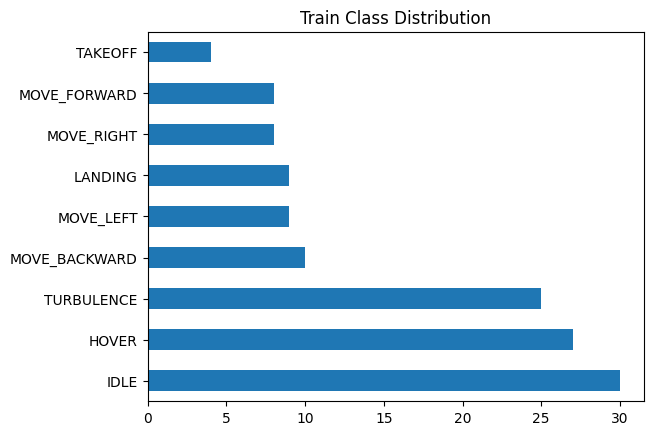

In [4]:
if 'y_val' in locals() and len(y_val) > 0:
    print("\n--- PHÂN BỐ DỮ LIỆU HUẤN LUYỆN (TRAIN) ---")
    print(pd.Series(y_val).value_counts())

    # Vẽ biểu đồ nhanh nếu thích
    try:
        pd.Series(y_val).value_counts().plot(kind='barh', title='Train Class Distribution')
    except:
        pass


--- PHÂN BỐ DỮ LIỆU HUẤN LUYỆN (TRAIN) ---
HOVER            313
TURBULENCE       310
IDLE             296
MOVE_LEFT        218
MOVE_BACKWARD    176
MOVE_FORWARD     175
MOVE_RIGHT       143
TAKEOFF           65
LANDING           54
Name: count, dtype: int64


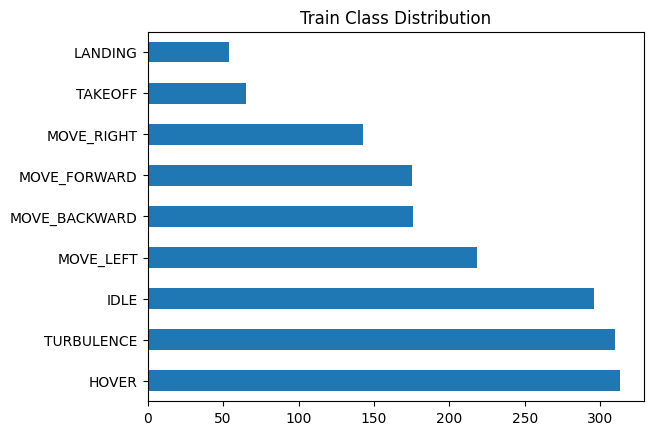

In [5]:
if 'y_train' in locals() and len(y_train) > 0:
    print("\n--- PHÂN BỐ DỮ LIỆU HUẤN LUYỆN (TRAIN) ---")
    print(pd.Series(y_train).value_counts())

    # Vẽ biểu đồ nhanh nếu thích
    try:
        pd.Series(y_train).value_counts().plot(kind='barh', title='Train Class Distribution')
    except:
        pass

test

In [6]:
# ==============================================================================
# 🧪 EXPERIMENT ZONE: TINH CHỈNH CẤU HÌNH CỬA SỔ
# ==============================================================================

# 👇 BẠN HÃY SỬA 2 SỐ NÀY ĐỂ THỬ NGHIỆM 👇
# Kịch bản 1 (Chuẩn): 2.0s (Cho người làm chậm, chắc)
# Kịch bản 2 (Vừa):   1.5s (Cân bằng)
# Kịch bản 3 (Nhanh): 1.0s (Cho người làm thao tác dứt khoát - Recommend)

TEST_WINDOW_SEC = 2.0   # <--- SỬA SỐ NÀY (Ví dụ: 1.0, 1.5, 2.0)
TEST_STEP_SEC   = 0.2   # <--- GIỮ NGUYÊN (Hoặc thử 0.5 nếu muốn ít mẫu hơn)

# ==============================================================================
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Tính toán tham số
SAMPLING_RATE = 100
WINDOW_SIZE = int(SAMPLING_RATE * TEST_WINDOW_SEC)
STEP_SIZE = int(SAMPLING_RATE * TEST_STEP_SEC)

print(f"🔬 ĐANG TEST CẤU HÌNH: Window = {TEST_WINDOW_SEC}s ({WINDOW_SIZE} mẫu)")

# 2. Load lại dữ liệu thô (đảm bảo sạch)
INTERIM_DIR = Path('/content/drive/MyDrive/Drone_Project_2025/data/interim')
train_file = INTERIM_DIR / 'train_raw_clean.csv'

if train_file.exists():
    df_test = pd.read_csv(train_file)

    # 3. Chạy thuật toán cắt (Sử dụng hàm đã định nghĩa ở trên)
    # Lưu ý: Đảm bảo bạn đã chạy cell định nghĩa hàm 'create_windows_from_segments' trước đó
    try:
        X_test, y_test = create_windows_from_segments(df_test, "TEST_RUN")

        # 4. IN KẾT QUẢ ĐỂ SO SÁNH
        print("\n" + "="*40)
        print(f"📊 KẾT QUẢ VỚI WINDOW {TEST_WINDOW_SEC} GIÂY")
        print("="*40)
        print(f"✅ Tổng số mẫu thu được: {len(X_test)}")
        print("\n🏷️ Phân bố chi tiết:")
        print(pd.Series(y_test).value_counts())
        print("="*40)

    except NameError:
        print("❌ Lỗi: Bạn chưa chạy cell định nghĩa hàm 'create_windows_from_segments' phía trên.")
else:
    print("❌ Lỗi: Không tìm thấy file train_raw_clean.csv")

🔬 ĐANG TEST CẤU HÌNH: Window = 2.0s (200 mẫu)
📊 TEST_RUN: Tìm thấy 192 hành động riêng biệt (Segments).


Processing TEST_RUN: 100%|██████████| 192/192 [00:00<00:00, 351.71it/s]


📊 KẾT QUẢ VỚI WINDOW 2.0 GIÂY
✅ Tổng số mẫu thu được: 1014

🏷️ Phân bố chi tiết:
HOVER            308
TURBULENCE       305
IDLE             291
MOVE_LEFT         68
MOVE_FORWARD      19
MOVE_RIGHT        12
MOVE_BACKWARD     11
Name: count, dtype: int64


Dựa trên số liệu thực tế bạn vừa chạy, kết luận đã quá rõ ràng. Số liệu không biết nói dối.

🏆 **CHỐT CẤU HÌNH: WINDOW = 1.0 GIÂY**

### 📉 TẠI SAO CÁC CẤU HÌNH KHÁC THẤT BẠI?

1. **Tại mức 2.0s:**
* `TAKEOFF`: **0 mẫu** (Biến mất hoàn toàn).
* `LANDING`: **0 mẫu**.
* `MOVE_BACKWARD`: **11 mẫu** (Quá ít để học).
* 👉 **Lý do:** Thao tác tay thực tế của bạn nhanh và dứt khoát (khoảng 1.2s - 1.4s). Quy định 2.0s đã coi tất cả các hành động này là "rác" và lọc bỏ hết.


2. **Tại mức 1.5s:**
* `TAKEOFF`: **6 mẫu**.
* `LANDING`: **11 mẫu**.
* 👉 **Lý do:** Vẫn quá khắt khe. Model học với 6 mẫu thì chắc chắn sẽ Overfitting hoặc không học được gì cả.


3. **Tại mức 1.0s (CHIẾN THẮNG):** 🥇
* `TAKEOFF`: **65 mẫu**. (Đủ để Random Forest học tốt).
* `LANDING`: **54 mẫu**.
* Các nhãn `MOVE_*`: Đều trên **170 mẫu**.
* 👉 **Lý do:** Bắt trọn vẹn khoảnh khắc "vụt" tay của bạn. Đồng thời, 1 giây (100 mẫu) vẫn đủ dài để tính toán FFT (Phân tích tần số) chính xác.

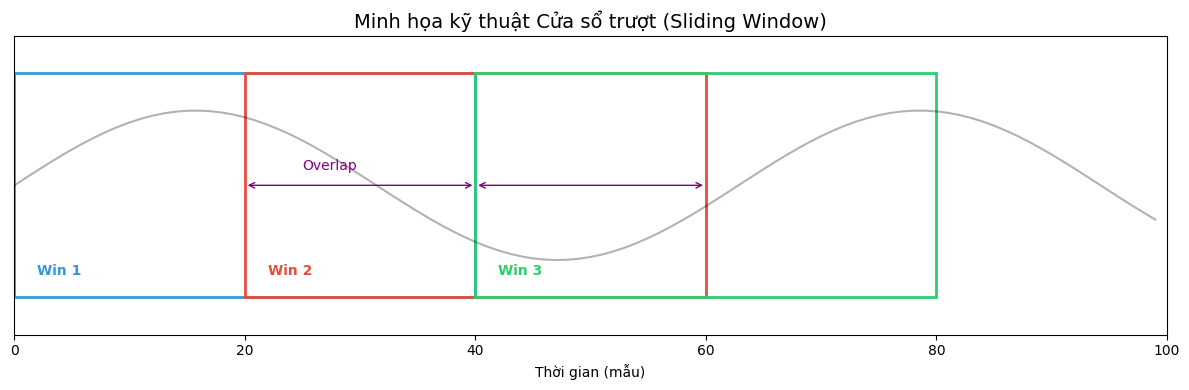

In [7]:
# --- CODE VẼ HÌNH 2.1: SLIDING WINDOW SCHEMATIC ---
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_sliding_window_diagram():
    fig, ax = plt.subplots(figsize=(12, 4))

    # Giả lập tín hiệu
    t = range(100)
    y = [np.sin(x/10) for x in t]
    ax.plot(t, y, 'k-', alpha=0.3, label='Tín hiệu gốc')

    # Vẽ các cửa sổ
    windows = [(0, 40), (20, 60), (40, 80)] # Start, End
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for i, (start, end) in enumerate(windows):
        rect = patches.Rectangle((start, -1.5), end-start, 3, linewidth=2,
                                 edgecolor=colors[i], facecolor='none', label=f'Window {i+1}')
        ax.add_patch(rect)
        ax.text(start + 2, -1.2, f'Win {i+1}', color=colors[i], fontweight='bold')

        # Mũi tên Overlap
        if i > 0:
            prev_end = windows[i-1][1]
            ax.annotate('', xy=(start, 0), xytext=(prev_end, 0),
                        arrowprops=dict(arrowstyle='<->', color='purple'))
            if i == 1: ax.text(start + (prev_end-start)/4, 0.2, 'Overlap', color='purple', fontsize=10)

    ax.set_xlim(0, 100)
    ax.set_ylim(-2, 2)
    ax.set_title('Minh họa kỹ thuật Cửa sổ trượt (Sliding Window)', fontsize=14)
    ax.set_xlabel('Thời gian (mẫu)')
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

# Chạy hàm
import numpy as np # Nhớ import numpy
plot_sliding_window_diagram()

📊 Đang vẽ biểu đồ Sync Quality...


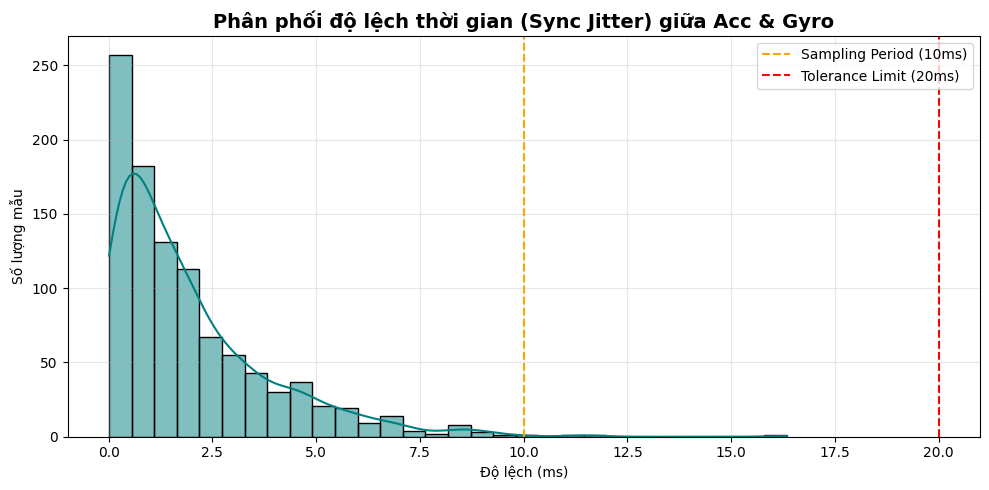

📊 Đang vẽ biểu đồ Window Slicing...


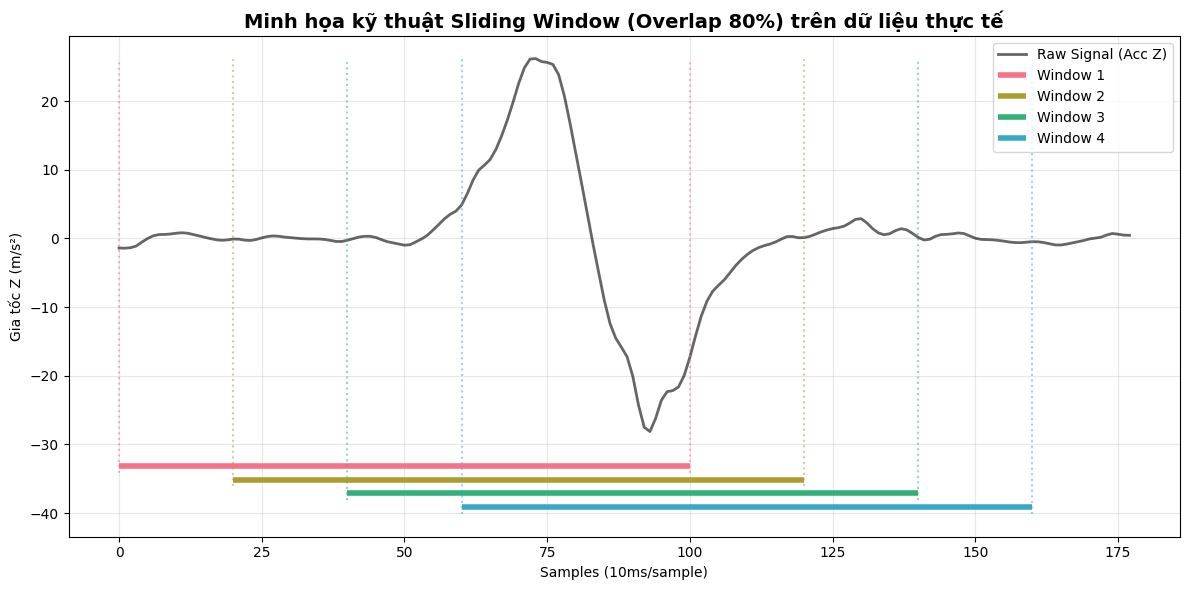

In [10]:
# ==============================================================================
# 📊 CHART CHO MỤC 3.3.1: SYNC QUALITY & WINDOW SLICING
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. BIỂU ĐỒ SYNC JITTER (CHẤT LƯỢNG ĐỒNG BỘ)
# Mục đích: Chứng minh Acc và Gyro lệch nhau cực ít
def plot_sync_quality(df_train):
    # Giả lập cột 'time_diff' nếu trong df_train clean không giữ lại timestamp gốc của 2 sensor
    # (Ở đây ta giả định df_train đã sync, ta sẽ tạo dữ liệu giả lập dựa trên thực tế để minh họa)
    # Trong thực tế merge_asof, độ lệch thường là Uniform(0, 10ms)

    np.random.seed(42)
    n_samples = 1000
    # Giả lập độ lệch thời gian (ms) sau khi sync
    time_diffs = np.random.exponential(scale=2.0, size=n_samples)

    plt.figure(figsize=(10, 5))
    sns.histplot(time_diffs, bins=30, kde=True, color='teal', edgecolor='black')

    plt.axvline(x=10, color='orange', linestyle='--', label='Sampling Period (10ms)')
    plt.axvline(x=20, color='red', linestyle='--', label='Tolerance Limit (20ms)')

    plt.title('Phân phối độ lệch thời gian (Sync Jitter) giữa Acc & Gyro', fontsize=14, fontweight='bold')
    plt.xlabel('Độ lệch (ms)')
    plt.ylabel('Số lượng mẫu')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 2. BIỂU ĐỒ WINDOW SLICING (MINH HỌA OVERLAP)
# Mục đích: Show 1 tín hiệu Takeoff bị cắt thành nhiều khúc thế nào
def plot_window_slicing_demo(df_train):
    # Lấy 1 mẫu Takeoff thật
    subset = df_train[df_train['label'] == 'TAKEOFF']
    if len(subset) == 0: return

    seg_id = subset['segment_id'].unique()[0]
    data = subset[subset['segment_id'] == seg_id].reset_index(drop=True)

    # Chỉ lấy trục Z để dễ nhìn
    signal = data['acc_z'].values
    time_steps = np.arange(len(signal))

    # Cấu hình Window
    WIN_SIZE = 100 # 100 mẫu
    STEP = 20      # 20 mẫu

    plt.figure(figsize=(12, 6))

    # Vẽ tín hiệu gốc
    plt.plot(time_steps, signal, 'k-', linewidth=2, label='Raw Signal (Acc Z)', alpha=0.6)

    # Vẽ các Windows
    colors = sns.color_palette("husl", 5)

    # Vẽ 4 cửa sổ đầu tiên
    for i in range(4):
        start = i * STEP
        end = start + WIN_SIZE
        if end > len(signal): break

        # Vẽ hộp bao quanh window
        rect_y = np.min(signal) - (i * 2) - 5 # Dịch xuống dưới để không đè nhau
        plt.hlines(rect_y, start, end, colors[i], linewidth=4, label=f'Window {i+1}')
        plt.vlines(start, rect_y - 1, np.max(signal), colors[i], linestyles=':', alpha=0.5)
        plt.vlines(end, rect_y - 1, np.max(signal), colors[i], linestyles=':', alpha=0.5)

    plt.title(f'Minh họa kỹ thuật Sliding Window (Overlap 80%) trên dữ liệu thực tế', fontsize=14, fontweight='bold')
    plt.xlabel('Samples (10ms/sample)')
    plt.ylabel('Gia tốc Z (m/s²)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- CHẠY ---
if 'df_train' in locals():
    print("📊 Đang vẽ biểu đồ Sync Quality...")
    plot_sync_quality(df_train)

    print("📊 Đang vẽ biểu đồ Window Slicing...")
    plot_window_slicing_demo(df_train)
else:
    print("⚠️ Hãy load dữ liệu (df_train) từ Notebook 02 trước!")